# Jev × EasyTurn：用文本基线观察测试集的语义偏好

本篇把 EasyTurn 音频交给现成 ASR，再用固定状态说明让通用决策模型 Jev 判断四类话轮状态。
我们关心：无需针对 EasyTurn 训练，文本基线能够接近到什么程度，以及这对测试集的语义特性有什么启示。
官方参考文本作为对照，帮助检查转写变化对判断的影响。

按数据准备、ASR、决策、评分依次运行，每个阶段保存结果，方便检查与续跑。
ASR 支持 CUDA、Apple Silicon 的 MPS 与 CPU，环境安装方法见 README。
已完成实验的结论及数据标注、合成启示见 [实验报告](EXPERIMENT_REPORT.md)。

## 1. 配置一次实验

先设置数据位置、试跑规模和要开启的阶段。

In [47]:
import hashlib
import json
import os
import re
import time
from importlib.metadata import version
from pathlib import Path

import numpy as np
import pandas as pd
import torch

DATASET_ID = "ASLP-lab/Easy-Turn-Testset"
DATASET_REVISION = "5812651dbab429b9a4fab293de7127bfb9a56650"
DATASET_DIR = Path("data/easyturn-testset")
ASR_MODEL = "Qwen/Qwen3-ASR-1.7B"
ASR_REVISION = "7278e1e70fe206f11671096ffdd38061171dd6e5"
ASR_MODEL_DIR = Path("models/qwen3-asr-1.7b")
if torch.cuda.is_available():
    ASR_DEVICE = "cuda:0"
elif torch.backends.mps.is_available():
    ASR_DEVICE = "mps"
else:
    ASR_DEVICE = "cpu"
ASR_BATCH_SIZE = 8 if ASR_DEVICE.startswith("cuda") else 1
ASR_MAX_NEW_TOKENS = 1024

SAMPLES_PER_STRATUM = None  # 使用全部 800 条；设为 2 可先试跑 16 条。
SEED = 42
EXPERIMENT_MODELS = ["typesafe-ai/jev"]
INPUT_MODES = ["asr", "reference"]  # 相同样本的 ASR 与参考转写对照。

RUN_DOWNLOAD = False
RUN_ASR = False
RUN_JEV = False
CACHE_DIR = Path("results/easyturn/cache")
OUTPUT_DIR = CACHE_DIR.parent
REQUEST_INTERVAL_SECONDS = 1.0  # 留出服务限流所需的请求间隔。

`RUN_DOWNLOAD`、`RUN_ASR`、`RUN_JEV` 分别控制测试集下载、本地转写和 API 调用，当前都关闭。有转写缓存时可以关闭 ASR，继续使用已保存的文本。

`SAMPLES_PER_STRATUM=2` 按“类别 × 来源”抽取 16 条试跑；当前的 `None` 使用全部 800 条。`EXPERIMENT_MODELS` 默认只有 Jev，加入 `spx-cd-flash` 或 `spx-cd-pro` 可以比较模型。

`INPUT_MODES=["asr", "reference"]` 让同一条样本分别用 ASR 识别文本和数据集参考文本调用模型，每次传入一份文本。比较两次结果，可以观察转写差异对分类的影响。只选 `reference` 时可以保持 `RUN_ASR=False`。

`DATASET_REVISION` 和 `ASR_REVISION` 是 Hugging Face 仓库的提交 ID，下载时分别指定测试集和 ASR 模型的版本。

## 2. 读取官方测试集

下载固定版本的数据，或复用同版本的本地目录。

In [48]:
from huggingface_hub import snapshot_download

if RUN_DOWNLOAD:
    snapshot_download(
        repo_id=DATASET_ID,
        repo_type="dataset",
        revision=DATASET_REVISION,
        local_dir=DATASET_DIR,
        allow_patterns=["testset/**", "README.md"],
    )

TESTSET_DIR = DATASET_DIR / "testset"
if not TESTSET_DIR.is_dir():
    raise FileNotFoundError("请开启 RUN_DOWNLOAD，或设置包含 testset 的 DATASET_DIR。")
print("测试集目录：", TESTSET_DIR)

测试集目录： data/easyturn-testset/testset


官方数据以四个 `.list` 文件提供，每行是一个 JSON 对象，音频放在相邻目录。
下一步检查样本字段，并整理用于实验的记录。

In [49]:
list_paths = sorted(TESTSET_DIR.glob("*/*.list"))
if len(list_paths) != 4:
    raise ValueError(f"应有 4 个官方清单文件，实际找到 {len(list_paths)} 个。")

manifest_rows = []
for list_path in list_paths:
    for line in list_path.read_text().splitlines():
        item = json.loads(line)
        label_match = re.search(r"<(COMPLETE|INCOMPLETE|BACKCHANNEL|WAIT)>$", item["txt"])
        if label_match is None:
            raise ValueError(f"{item['key']} 缺少结尾标签。")
        label = label_match.group(1).lower()
        relative_audio = Path(item["wav"].removeprefix("./"))
        if relative_audio.parts[0] != label:
            raise ValueError(f"{item['key']} 的路径类别与标签不一致。")
        audio_path = (TESTSET_DIR / relative_audio).resolve()
        if not audio_path.is_relative_to(TESTSET_DIR.resolve()) or not audio_path.is_file():
            raise FileNotFoundError(item["wav"])
        source = relative_audio.parts[1]
        if source not in {"real", "synthetic"}:
            raise ValueError(f"未知来源：{source}")
        manifest_rows.append(
            {
                "id": item["key"],
                "audio_path": str(TESTSET_DIR / relative_audio),
                "gold": f"<{label}>",
                "source": source,
                "reference_text": item["txt"][: label_match.start()].strip(),
                "audio_sha256": hashlib.sha256(audio_path.read_bytes()).hexdigest(),
            }
        )
manifest = pd.DataFrame(manifest_rows)

这里从 `txt` 结尾读取标注，剥离标签后保存 `reference_text`。
`gold` 与 `source` 留在评分记录里；决策阶段单独构造只包含文本的输入。
音频哈希用于识别本地数据变化。

In [50]:
LABEL_ORDER = ["<complete>", "<incomplete>", "<backchannel>", "<wait>"]
expected_counts = dict(zip(LABEL_ORDER, [300, 300, 100, 100]))
if manifest.id.duplicated().any() or len(manifest) != 800:
    raise ValueError("官方测试集应包含 800 个唯一样本。")
if manifest.groupby("gold").size().to_dict() != expected_counts:
    raise ValueError("四类数量与官方测试集不一致。")

counts = pd.crosstab(manifest.gold, manifest.source).reindex(LABEL_ORDER)
if not (counts["real"] == counts["synthetic"]).all():
    raise ValueError("各类的真实与合成数量应相同。")
display(counts)

if SAMPLES_PER_STRATUM is None:
    selected = manifest.copy()
else:
    selected = (
        manifest.groupby(["gold", "source"], group_keys=False)
        .sample(n=SAMPLES_PER_STRATUM, random_state=SEED)
        .copy()
    )
selected = selected.sort_values("id").reset_index(drop=True)
print(f"本轮使用 {len(selected)} / {len(manifest)} 条音频。")

source,real,synthetic
gold,,
<complete>,150,150
<incomplete>,150,150
<backchannel>,50,50
<wait>,50,50


本轮使用 800 / 800 条音频。


这张四行表检查数据组成。类别 × 来源的抽样用于试跑；完整实验保留 300/300/100/100 的官方分布。
全测试集的逐类正确率和四类平均正确率对应 [EasyTurn 论文第 4 节](https://arxiv.org/abs/2509.23938)。

测试集真实录音与合成语音各占一半，状态由人工标注，合成音频通过 CosyVoice 2 生成。
四类状态的定义包含明确的语义线索，因此后续同时观察文本基线的整体表现与来源差异。
[官方测试集说明](https://huggingface.co/datasets/ASLP-lab/Easy-Turn-Testset/blob/main/README.md)

## 3. 定义四类决策

先把论文的状态说明交给 Jev。

In [51]:
CRITERIA = {
    "<complete>": "用户已完整表达意图，期待系统回应。",
    "<incomplete>": "用户表达尚未完成，暂停后还需要继续说。",
    "<backchannel>": "用户用简短附和表达倾听或理解。",
    "<wait>": "用户明确要求暂停当前交互或结束对话。",
}
INSTRUCTIONS = (
    "根据用户当前的文本片段，判断 Easy Turn 定义的话轮状态。"
    "请选出最符合当前表达意图的一个候选。"
    "完整的提问或请求通常是 complete；句子或意图尚未完成是 incomplete。"
    "简短的倾听反馈是 backchannel；明确要求停下或结束交互是 wait。"
    "文本来自语音转写，可能存在识别错误或不自然的标点。"
)

四个候选沿用论文第 2.1 节。特别留意 `wait` 的暂停/结束意图，和 `incomplete` 的未完成表达。
提示词固定后，再运行测试集；需要改提示词时，请为新的配置设置独立缓存目录。
这次只提供固定状态说明，不加入 few-shot 示例，也不对 Jev 进行任务训练，作为 zero-shot 文本基线。

In [52]:
experiment_config = {
    "dataset_id": DATASET_ID,
    "dataset_revision": DATASET_REVISION,
    "samples": selected[["id", "audio_sha256"]].to_dict("records"),
    "asr_model": ASR_MODEL,
    "asr_revision": ASR_REVISION,
    "asr_dtype": "bfloat16",
    "asr_device": ASR_DEVICE,
    "asr_batch_size": ASR_BATCH_SIZE,
    "asr_max_new_tokens": ASR_MAX_NEW_TOKENS,
    "asr_language": None,
    "models": EXPERIMENT_MODELS,
    "input_modes": INPUT_MODES,
    "criteria": CRITERIA,
    "instructions": INSTRUCTIONS,
    "sdk_version": version("simplex-ai-sdk"),
    "qwen_asr_version": version("qwen-asr"),
    "seed": SEED,
}
config_json = json.dumps(experiment_config, ensure_ascii=False, sort_keys=True)
run_dir = CACHE_DIR
config_path = run_dir / "config.json"
if config_path.exists():
    saved_config = json.loads(config_path.read_text())
    if saved_config != experiment_config:
        raise ValueError(
            "当前配置与已有缓存不同。请将 CACHE_DIR 改为新的缓存目录，"
            "例如 results/easyturn/trial/cache，再运行本节。"
        )
run_dir.mkdir(parents=True, exist_ok=True)
config_path.write_text(config_json)
selected.to_json(run_dir / "manifest.jsonl", orient="records", lines=True, force_ascii=False)
ASR_CACHE = run_dir / "asr.jsonl"
DECISION_CACHE = run_dir / "decisions.jsonl"
print("本轮缓存目录：", run_dir)

本轮缓存目录： results/easyturn/cache


`CACHE_DIR` 指定运行缓存，默认使用 `results/easyturn/cache/`。
`config.json` 保存实验设置；代码先比较新旧配置，再复用已有转写和预测。
修改样本、模型、设备、提示词或参数后，需要设置新的缓存目录。
另一次实验可以使用 `results/easyturn/trial/cache/`，其分析结果会写入对应的 `trial/`。

缓存文件各自负责一个阶段：

- `config.json`：配置检查，防止复用另一套实验的缓存。
- `manifest.jsonl`：本轮样本 ID、音频路径、参考文本、标注和音频哈希。
- `asr.jsonl`：ASR 转写与状态；同一 ID 使用最后一条记录。
- `decisions.jsonl`：实际请求、原始 API 响应与状态；按样本、模型和输入形式恢复进度。
- `model_catalog.json`：调用时查询的模型目录与提供方信息。

`OUTPUT_DIR` 默认取缓存目录的上一级，保存后续分析。转写和 API 调用完成后，
可以关闭运行开关，仅从缓存重新计算这些结果。

## 4. 本地 ASR：先把语音转成文字

加载已有转写缓存，再根据开关加载模型。

In [53]:
asr_records = []
if ASR_CACHE.exists():
    asr_records = [json.loads(line) for line in ASR_CACHE.read_text().splitlines()]
asr_by_id = {record["id"]: record for record in asr_records}
pending_audio = [
    sample
    for sample in selected.to_dict("records")
    if asr_by_id.get(sample["id"], {}).get("status") != "ok"
]
print(f"待转写：{len(pending_audio)} 条。")

if RUN_ASR and pending_audio:
    import torch
    from qwen_asr import Qwen3ASRModel

    if (ASR_MODEL_DIR / "config.json").is_file():
        asr_checkpoint = str(ASR_MODEL_DIR)
    else:
        asr_checkpoint = snapshot_download(
            repo_id=ASR_MODEL,
            revision=ASR_REVISION,
            local_dir=ASR_MODEL_DIR,
        )
    asr_model = Qwen3ASRModel.from_pretrained(
        asr_checkpoint,
        dtype=torch.bfloat16,
        device_map=ASR_DEVICE,
        max_inference_batch_size=ASR_BATCH_SIZE,
        max_new_tokens=ASR_MAX_NEW_TOKENS,
    )

待转写：1 条。


这里使用 [Qwen3-ASR 官方 Transformers 接口](https://github.com/QwenLM/Qwen3-ASR)。设备默认按 CUDA、MPS、CPU 的顺序自动选择，也可以在配置 cell 中修改 `ASR_DEVICE`。CUDA 默认每批 8 条，MPS 与 CPU 每批 1 条；手动改设备时同时检查 `ASR_BATCH_SIZE`。

代码优先加载 `ASR_MODEL_DIR` 中已有的模型；该目录没有 `config.json` 时，才按 `ASR_REVISION` 下载快照。已有模型目录应对应所配置的版本。

In [54]:
if RUN_ASR and pending_audio:
    with ASR_CACHE.open("a") as cache_file:
        for start in range(0, len(pending_audio), ASR_BATCH_SIZE):
            batch = pending_audio[start : start + ASR_BATCH_SIZE]
            try:
                transcriptions = asr_model.transcribe(
                    audio=[sample["audio_path"] for sample in batch],
                    language=None,
                )
                if len(transcriptions) != len(batch):
                    raise ValueError("ASR 返回数量与输入数量不一致。")
                batch_records = [
                    {
                        "id": sample["id"],
                        "status": "ok" if result.text.strip() else "empty",
                        "text": result.text.strip(),
                        "language": result.language,
                    }
                    for sample, result in zip(batch, transcriptions)
                ]
            except Exception as exc:
                batch_records = [
                    {"id": sample["id"], "status": "error", "error_type": type(exc).__name__}
                    for sample in batch
                ]
            for record in batch_records:
                cache_file.write(json.dumps(record, ensure_ascii=False) + "\n")
                asr_by_id[record["id"]] = record
            cache_file.flush()
            completed = min(start + len(batch), len(pending_audio))
            if start // ASR_BATCH_SIZE % 25 == 0 or completed == len(pending_audio):
                print(f"ASR：已处理 {completed}/{len(pending_audio)} 条。")

    retry_records = [asr_by_id[sample["id"]] for sample in pending_audio]
    retry_counts = pd.Series([record["status"] for record in retry_records]).value_counts()
    print(
        f"本次结果：非空 {retry_counts.get('ok', 0)} 条，"
        f"空转写 {retry_counts.get('empty', 0)} 条，"
        f"失败 {retry_counts.get('error', 0)} 条。"
    )
    for record in retry_records:
        if record["status"] != "ok":
            print(f"  {record['id']} · {record['status']}")
else:
    print("ASR 阶段关闭，或没有待转写音频。")

ASR 阶段关闭，或没有待转写音频。


`language=None` 让模型自动识别语言。转写去掉首尾空白后保存，非空结果标记为 `ok`，空结果标记为 `empty`，异常标记为 `error`。
再次开启 ASR 时会重试空转写和失败项，复用已有的 `ok` 结果。批次失败后先检查运行设备、模型路径与环境，再重新运行加载与转写两个 cell。
“已处理”表示已完成一次尝试；随后显示本次非空、空转写和失败数量。缓存按行追加重试记录，同一个 ID 采用最后一条记录。

In [55]:
for sample in selected.head(3).to_dict("records"):
    record = asr_by_id.get(sample["id"], {})
    print(sample["id"], "·", record.get("status", "pending"))
    print("ASR：", record.get("text", "尚无转写"))
    print("参考：", sample["reference_text"])
    print()

if RUN_ASR and pending_audio:
    del asr_model
    if ASR_DEVICE.startswith("cuda"):
        torch.cuda.empty_cache()
    elif ASR_DEVICE == "mps":
        torch.mps.empty_cache()

backchannel_real_001 · ok
ASR： 嗯，也是。
参考： 嗯，也是

backchannel_real_002 · ok
ASR： 好啊，好啊。
参考： 好啊好啊

backchannel_real_003 · ok
ASR： 哦，对对对。
参考： 哦对对对



这三条预览用于对照识别文本与参考文本。后面的 `asr` 请求使用缓存中的转写，`reference` 请求使用数据集参考文本。
本次加载过 ASR 模型时，预览后释放模型内存；Jev 通过 API 调用。

比较转写与参考文本，检查识别错误和空输入。

In [56]:
# 从磁盘重新读取最新结果，便于单独重跑质量检查。
asr_by_id = {}
if ASR_CACHE.exists():
    for line in ASR_CACHE.read_text().splitlines():
        if line.strip():
            record = json.loads(line)
            asr_by_id[record["id"]] = record

import unicodedata

asr_quality_rows = []
for sample in selected.to_dict("records"):
    record = asr_by_id.get(sample["id"], {})
    if record.get("status") not in {"ok", "empty"}:
        continue
    reference = re.sub(
        r"\W+", "", unicodedata.normalize("NFKC", sample["reference_text"]).casefold()
    )
    prediction = re.sub(
        r"\W+", "", unicodedata.normalize("NFKC", record.get("text", "")).casefold()
    )

    previous = list(range(len(prediction) + 1))
    for row_index, reference_character in enumerate(reference, start=1):
        current = [row_index]
        for column_index, predicted_character in enumerate(prediction, start=1):
            current.append(
                min(
                    current[-1] + 1,
                    previous[column_index] + 1,
                    previous[column_index - 1] + (reference_character != predicted_character),
                )
            )
        previous = current
    asr_quality_rows.append(
        {
            "source": sample["source"],
            "status": record["status"],
            "reference_chars": len(reference),
            "edit_distance": previous[-1],
            "exact_match": reference == prediction,
            "empty": record["status"] == "empty",
        }
    )
asr_quality = pd.DataFrame(asr_quality_rows)

上面先统一字符形式、去掉标点与空白，再计算字符编辑距离。每次插入、删除或替换一个字符计一次错误；空转写保留在统计中。这些归一化文本用于计算指标，Jev 继续接收原始转写。

In [57]:
quality_snapshot = {}
if not asr_quality.empty:
    asr_source_quality = asr_quality.groupby("source").agg(
        n=("source", "size"),
        reference_chars=("reference_chars", "sum"),
        edits=("edit_distance", "sum"),
        exact_match=("exact_match", "mean"),
        empty=("empty", "sum"),
    )
    asr_source_quality["cer"] = asr_source_quality.edits / asr_source_quality.reference_chars
    total_cer = asr_quality.edit_distance.sum() / asr_quality.reference_chars.sum()
    selected_statuses = pd.Series(
        [asr_by_id.get(sample_id, {}).get("status", "pending") for sample_id in selected.id]
    ).value_counts()
    print(
        f"非空转写：{selected_statuses.get('ok', 0)}/{len(selected)} 条；"
        f"空转写：{selected_statuses.get('empty', 0)} 条；"
        f"失败：{selected_statuses.get('error', 0)} 条；"
        f"待转写：{selected_statuses.get('pending', 0)} 条。"
    )
    print(f"CER 统计样本（含空转写）：{len(asr_quality)} 条；整体 CER：{total_cer:.2%}。")

    quality_snapshot = {}
    quality_groups = [("all", asr_quality), *asr_quality.groupby("source")]
    for name, group in quality_groups:
        reference_chars = int(group.reference_chars.sum())
        quality_snapshot[name] = {
            "n": len(group),
            "cer": float(group.edit_distance.sum() / reference_chars) if reference_chars else None,
            "normalized_exact_match": float(group.exact_match.mean()),
            "statuses": {key: int(value) for key, value in group.status.value_counts().items()},
        }
    display(asr_source_quality[["n", "empty", "cer", "exact_match"]].round(4))
else:
    print("完成 ASR 后查看转写质量。")

非空转写：799/800 条；空转写：1 条；失败：0 条；待转写：0 条。
CER 统计样本（含空转写）：800 条；整体 CER：1.50%。


,n,empty,cer,exact_match
source,,,,
real,400,1,0.0233,0.8225
synthetic,400,0,0.0073,0.9475


**CER（字符错误率）** 是总编辑次数除以参考字符总数，越低越好。`exact_match` 表示归一化后完全一致的样本比例，`empty` 记录空转写数量。按真实/合成来源分别查看，可以帮助解释后面的分类差异。
重试后依次重跑前面两个质量检查 cell：第一个从缓存读取最新记录并计算指标，第二个显示最新统计。最终保存章节将这部分结果写入 `metrics.json` 的 `asr_quality`。

## 5. 用同一个 SDK 调用 Jev

先准备只含文本的请求，并检查待调用数量。

In [58]:
from getpass import getpass
from simplex_ai import Choice, SimplexClient

if len(set(EXPERIMENT_MODELS)) != len(EXPERIMENT_MODELS):
    raise ValueError("EXPERIMENT_MODELS 中有重复模型。")
if not INPUT_MODES or not set(INPUT_MODES) <= {"asr", "reference"}:
    raise ValueError("INPUT_MODES 只能包含 asr 和 reference。")

decision_records = []
if DECISION_CACHE.exists():
    decision_records = [json.loads(line) for line in DECISION_CACHE.read_text().splitlines()]
decision_by_key = {
    (record["id"], record["model"], record["input_mode"]): record for record in decision_records
}
requests = []
for sample in selected.to_dict("records"):
    for input_mode in INPUT_MODES:
        if input_mode == "asr":
            asr_record = asr_by_id.get(sample["id"], {})
            text = asr_record.get("text", "") if asr_record.get("status") == "ok" else ""
        else:
            text = sample["reference_text"]
        if text:
            for model in EXPERIMENT_MODELS:
                request_key = (sample["id"], model, input_mode)
                if decision_by_key.get(request_key, {}).get("status") != "ok":
                    requests.append(
                        {
                            "id": sample["id"],
                            "model": model,
                            "input_mode": input_mode,
                            "state": {"user_text": text},
                        }
                    )
# 优先采集参考转写，先检查文本本身的分类表现。
requests.sort(key=lambda request: request["input_mode"] != "reference")
print(f"待发送：{len(requests)} 次调用；RUN_JEV={RUN_JEV}。")

待发送：0 次调用；RUN_JEV=False。


每次请求的 `state` 只有 `user_text`。标签、音频路径和来源留在评分清单中。`input_mode` 记录文本来源，缓存键由样本、模型和输入形式组成。空转写不会生成 ASR 请求。

当前配置包含一个模型、两种输入形式，全量最多 1,600 次请求；16 条试跑最多 32 次。成功缓存会减少新增调用。代码优先排列参考文本请求，方便先查看文本本身的分类表现；确认待调用数量后再开启 `RUN_JEV`。

In [59]:
if RUN_JEV and requests:
    api_key = os.getenv("SIMPLEX_API_TOKEN") or getpass("Surd AI API key：")
    client = SimplexClient(api_key=api_key, base_url="https://api.surdai.com")
    catalog = client.models()
    (run_dir / "model_catalog.json").write_text(json.dumps(catalog, ensure_ascii=False))
    for item in catalog["data"]:
        if item["id"] in EXPERIMENT_MODELS:
            print(item["id"], "· provider：", item.get("provider"))
else:
    print("Jev 阶段关闭，或没有待发送请求。")

Jev 阶段关闭，或没有待发送请求。


`SimplexClient` 沿用 Surd AI 的 key；Jev 的模型标识是 `typesafe-ai/jev`。
目录同时保存服务报告的提供方，便于记录本次访问路径。
Jev 支持文本 `Choice`，这次只使用四选一。

In [60]:
def predict_turn_state(request):
    record = dict(request)
    try:
        result = client.system_one(
            model=request["model"],
            state=request["state"],
            questions={
                "turn_state": Choice(instructions=INSTRUCTIONS, criteria=CRITERIA),
            },
        )
        record["response"] = result.model_dump()
        answer = result.answers["turn_state"]
        probabilities = answer.probabilities or {}
        values = np.array([probabilities.get(label, np.nan) for label in LABEL_ORDER])
        valid = (
            answer.choice in LABEL_ORDER
            and set(probabilities) == set(LABEL_ORDER)
            and np.isfinite(values).all()
            and ((values >= 0) & (values <= 1)).all()
            and values.sum() > 0
            and abs(values.sum() - 1) <= 0.02000001
        )
        record["status"] = "ok" if valid else "invalid"
    except Exception as exc:
        record["status"] = "error"
        record["error_type"] = type(exc).__name__
        record["http_status"] = getattr(exc, "status_code", None)
        record["retry_after_seconds"] = getattr(exc, "retry_after", None)
    return record

`predict_turn_state()` 完成一次调用并检查候选概率，保留成功响应或错误状态。下面的采集循环控制请求间隔，逐条保存缓存，并在服务限流或连续失败时停止。

In [61]:
if RUN_JEV and requests:
    consecutive_errors = 0
    try:
        with DECISION_CACHE.open("a") as cache_file:
            for index, request in enumerate(requests, start=1):
                time.sleep(REQUEST_INTERVAL_SECONDS)
                record = predict_turn_state(request)
                consecutive_errors = 0 if record["status"] == "ok" else consecutive_errors + 1

                cache_file.write(json.dumps(record, ensure_ascii=False) + "\n")
                cache_file.flush()
                key = (record["id"], record["model"], record["input_mode"])
                decision_by_key[key] = record
                if index % 10 == 0 or index == len(requests):
                    print(f"Jev：已处理 {index}/{len(requests)} 次调用。")
                if record.get("http_status") in {401, 402, 403, 429} or consecutive_errors >= 5:
                    print("请求连续失败或服务限制，检查缓存状态后再继续。")
                    break
    finally:
        client.close()

每个原始响应都保存下来，四个候选的概率需要完整且位于 0 到 1 之间。
四个概率各保留两位小数时，总和可能有最多 0.02 的舍入误差；
校验接受这个范围，评分前将各项除以总和，得到和为 1 的分布。
无效响应与 API 失败保留在缓存中，重跑会重新请求这些项。
执行中断后，已落盘的成功结果会被下一次运行复用。

## 6. 对齐 EasyTurn 的评分

把每条样本的预测与标注连接起来，先检查实验覆盖情况。

In [62]:
evaluation_rows = []
for model in EXPERIMENT_MODELS:
    for input_mode in INPUT_MODES:
        for sample in selected.to_dict("records"):
            key = (sample["id"], model, input_mode)
            record = decision_by_key.get(key, {})
            response = record.get("response", {})
            answer = response.get("answers", {}).get("turn_state", {})
            valid = record.get("status") == "ok"
            asr_status = asr_by_id.get(sample["id"], {}).get("status", "pending")
            status = record.get("status", "pending")
            if input_mode == "asr" and asr_status != "ok":
                status = f"asr_{asr_status}"
            evaluation_rows.append(
                {
                    "id": sample["id"],
                    "gold": sample["gold"],
                    "source": sample["source"],
                    "model": model,
                    "input_mode": input_mode,
                    "status": status,
                    "choice": answer.get("choice") if valid else None,
                    "probabilities": (
                        {
                            label: probability / sum(answer["probabilities"].values())
                            for label, probability in answer["probabilities"].items()
                        }
                        if valid else None
                    ),
                    "inference_ms": response.get("inference_ms") if valid else None,
                }
            )
evaluation = pd.DataFrame(evaluation_rows)
evaluation["correct"] = evaluation.choice == evaluation.gold
display(evaluation.groupby(["model", "input_mode", "status"]).size().rename("n").to_frame())

n
model           input_mode status        
typesafe-ai/jev asr        asr_empty    1
                           ok         799
                reference  ok         800

分类分母保留本轮全部样本。ASR 失败、空转写、API 失败、无效响应和尚未运行的样本都没有正确预测。
全量运行结束后应检查这张状态表，再阅读分数；中途显示的分数随完成覆盖率变化。

In [63]:
class_scores = (
    evaluation.groupby(["model", "input_mode", "gold"])
    .agg(n=("id", "size"), correct=("correct", "sum"), accuracy=("correct", "mean"))
    .reset_index()
)
summary = evaluation.groupby(["model", "input_mode"]).agg(
    n=("id", "size"), accuracy=("correct", "mean")
)
summary["macro_accuracy"] = class_scores.groupby(["model", "input_mode"]).accuracy.mean()
summary["valid_n"] = evaluation[evaluation.status == "ok"].groupby(["model", "input_mode"]).size()
summary["valid_n"] = summary.valid_n.fillna(0).astype(int)
summary["coverage"] = summary.valid_n / summary.n
print("本轮规模：", "完整测试集" if len(selected) == 800 else "试跑子集")
display(summary.round(4))

本轮规模： 完整测试集


n  accuracy  macro_accuracy  valid_n  coverage
model           input_mode                                                  
typesafe-ai/jev asr         800    0.8975          0.9217      799    0.9988
                reference   800    0.9438          0.9542      800    1.0000

`accuracy` 是所有样本中预测正确的比例；`macro_accuracy` 是四类正确率的平均，
对应论文的 ACC_avg。`coverage` 显示获得有效概率响应的样本比例。
下一张表只比较四个类别，便于定位差异。

In [64]:
paper_accuracy = pd.Series(
    [0.9633, 0.9767, 0.9100, 0.9800], index=LABEL_ORDER, name="EasyTurn paper"
)
class_comparison = class_scores.pivot(
    index="gold", columns=["model", "input_mode"], values="accuracy"
).reindex(LABEL_ORDER)
class_comparison.columns = [f"{model} / {mode}" for model, mode in class_comparison.columns]
class_comparison[paper_accuracy.name] = paper_accuracy
if len(selected) != 800:
    print("本轮为试跑子集；论文列使用官方全测试集。")
display((class_comparison * 100).round(2).rename_axis("每类正确率 (%)"))

,typesafe-ai/jev / asr,typesafe-ai/jev / reference,EasyTurn paper
每类正确率 (%),,,
<complete>,91.33,91.67,96.33
<incomplete>,83.33,95.00,97.67
<backchannel>,97.00,98.00,91.00
<wait>,97.00,97.00,98.00


论文参考列来自 [EasyTurn 表 2、表 3](https://arxiv.org/html/2509.23938v1#S4.SS2)，四类平均正确率为 95.75%。
Jev 的各列对应所选模型与文本输入形式。已完成的 800 条实验中，ASR → Jev 的四类平均正确率为 92.17%，相差 3.58 个百分点；参考文本 → Jev 为 95.42%，相差 0.33 个百分点。

通用文本决策模型无需针对 EasyTurn 训练就取得接近的成绩，为测试集较强的语义可预测性提供佐证。
结合后面的真实/合成切片和转写对照，进一步检查哪些线索使标签容易从文本恢复。

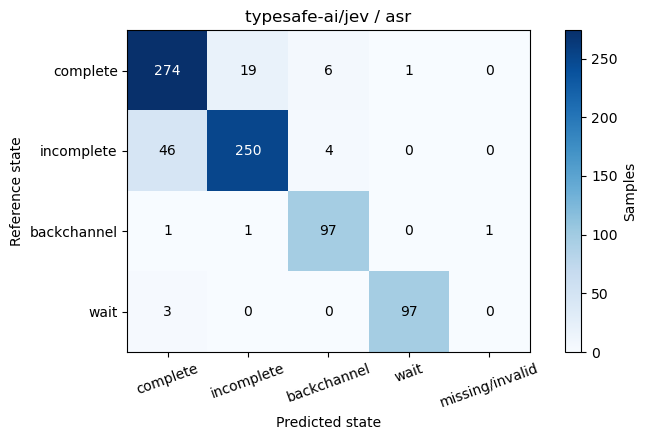

In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

PLOT_MODEL = EXPERIMENT_MODELS[0]
PLOT_INPUT_MODE = INPUT_MODES[0]
focus = evaluation[
    (evaluation.model == PLOT_MODEL) & (evaluation.input_mode == PLOT_INPUT_MODE)
].copy()
if focus.empty:
    raise ValueError("当前配置中没有指定的绘图模型或输入形式。")

matrix_labels = LABEL_ORDER + ["missing/invalid"]
predicted = focus.choice.fillna("missing/invalid")
full_matrix = confusion_matrix(focus.gold, predicted, labels=matrix_labels)
fig, ax = plt.subplots(figsize=(8, 4.5))
image = ax.imshow(full_matrix[:4], cmap="Blues")
ax.set_xticks(range(5), [label.strip("<>") for label in matrix_labels], rotation=20)
ax.set_yticks(range(4), [label.strip("<>") for label in LABEL_ORDER])
ax.set(
    xlabel="Predicted state", ylabel="Reference state", title=f"{PLOT_MODEL} / {PLOT_INPUT_MODE}"
)
for row in range(4):
    for column in range(5):
        count = full_matrix[row, column]
        text_color = "white" if count > full_matrix[:4].max() / 2 else "black"
        ax.text(
            column, row, str(count), ha="center", va="center", color=text_color
        )
fig.colorbar(image, ax=ax, label="Samples")
fig.tight_layout()
plt.show()

纵轴是标注，横轴是预测；最后一列收集缺失与无效结果。对角线表示正确预测，其他位置表示类别混淆。
`PLOT_MODEL` 和 `PLOT_INPUT_MODE` 指定本图及后续可靠性图、来源统计和错误预览使用的结果，默认取配置列表中的第一项。

## 7. 概率是否可靠？

在有效响应上计算概率指标，并同时保留覆盖率。

In [66]:
probability_rows = []
for (model, input_mode), group in evaluation.groupby(["model", "input_mode"]):
    valid = group[group.status == "ok"]
    if valid.empty:
        continue
    probabilities = np.array([[row[label] for label in LABEL_ORDER] for row in valid.probabilities])
    gold_indices = np.array([LABEL_ORDER.index(label) for label in valid.gold])
    targets = np.eye(4)[gold_indices]
    gold_probabilities = probabilities[np.arange(len(valid)), gold_indices]
    probability_rows.append(
        {
            "model": model,
            "input_mode": input_mode,
            "valid_n": len(valid),
            "coverage": len(valid) / len(group),
            "nll": float(-np.log(np.clip(gold_probabilities, 1e-12, 1)).mean()),
            "brier": float(((probabilities - targets) ** 2).sum(axis=1).mean()),
        }
    )
probability_summary = pd.DataFrame(
    probability_rows, columns=["model", "input_mode", "valid_n", "coverage", "nll", "brier"]
)
if probability_summary.empty:
    print("尚无有效概率，完成 Jev 阶段后再查看。")
else:
    display(probability_summary.round(4))

,model,input_mode,valid_n,coverage,nll,brier
0,typesafe-ai/jev,asr,799,0.9988,0.2693,0.1438
1,typesafe-ai/jev,reference,800,1.0000,0.1464,0.0855


NLL 是正确类别概率的负对数均值，计算前将概率下限设为 `1e-12`。Brier 是每条样本的四类概率与正确标签 0/1 向量之间的平方误差之和，再对样本求平均。
两者越低越好。这里仅计算 `ok` 响应，`coverage` 显示有效响应占本轮全部样本的比例。

ECE（10 个等宽区间）：0.0289；有效样本：799。


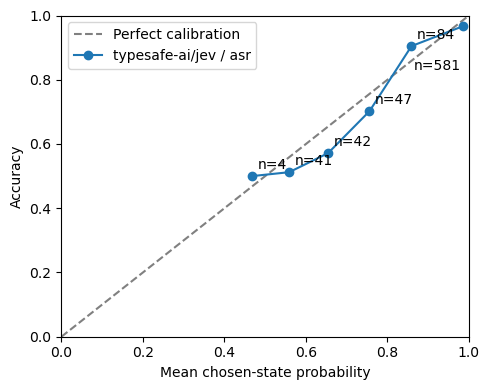

In [67]:
valid_focus = focus[focus.status == "ok"].copy()
reliability = pd.DataFrame()
if not valid_focus.empty:
    valid_focus["confidence"] = [
        probabilities[choice]
        for probabilities, choice in zip(valid_focus.probabilities, valid_focus.choice)
    ]
    valid_focus["bin"] = pd.cut(
        valid_focus.confidence, bins=np.linspace(0, 1, 11), include_lowest=True
    )
    reliability = (
        valid_focus.groupby("bin", observed=True)
        .agg(n=("id", "size"), confidence=("confidence", "mean"), accuracy=("correct", "mean"))
        .reset_index()
    )
    ece = (
        reliability.n / reliability.n.sum() * (reliability.confidence - reliability.accuracy).abs()
    ).sum()
    print(f"ECE（10 个等宽区间）：{ece:.4f}；有效样本：{len(valid_focus)}。")
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
    ax.plot(reliability.confidence, reliability.accuracy, "o-", label=f"{PLOT_MODEL} / {PLOT_INPUT_MODE}")
    for row in reliability.itertuples():
        ax.annotate(
            f"n={row.n}",
            (row.confidence, row.accuracy),
            xytext=(-36, -32) if row.confidence > 0.9 else (4, 5),
            textcoords="offset points",
        )
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean chosen-state probability", ylabel="Accuracy")
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("完成 Jev 阶段后生成可靠性图。")

图中按实际选中类别的概率分组；横轴是平均概率，纵轴是该组的正确率。
点越接近对角线，概率与正确率越接近。ECE 汇总十个区间的加权差异。
先看每组的样本数，再判断概率表现；16 条试跑主要用于检查流程。

## 8. 定位错误与查看服务端耗时

先看真实/合成切片，再展示最多五条错误。

In [68]:
source_scores = focus.groupby("source").agg(n=("id", "size"), accuracy=("correct", "mean"))
source_scores["macro_accuracy"] = (
    focus.groupby(["source", "gold"]).correct.mean().groupby("source").mean()
)
display(source_scores.round(4))

errors = focus[~focus.correct].head(5)
if errors.empty:
    print(f"没有预测错误：{len(focus)} 条样本全部正确。")
for row in errors.itertuples():
    sample = selected[selected.id == row.id].iloc[0]
    print(f"{row.id} · {row.source} · 状态：{row.status}")
    print("ASR：", asr_by_id.get(row.id, {}).get("text", "尚无转写"))
    print("参考：", sample.reference_text)
    print(f"标注：{row.gold} · 预测：{row.choice}")
    if row.probabilities:
        print("候选概率：", {label: round(row.probabilities[label], 3) for label in LABEL_ORDER})
    print()

,n,accuracy,macro_accuracy
source,,,
real,400,0.890,0.9133
synthetic,400,0.905,0.9300


backchannel_real_009 · real · 状态：asr_empty
ASR： 
参考： 嗯好好好
标注：<backchannel> · 预测：None

backchannel_real_021 · real · 状态：ok
ASR： 哦，行行行，我。
参考： 哦，行行行嗯
标注：<backchannel> · 预测：<incomplete>
候选概率： {'<complete>': 0.0, '<incomplete>': 0.76, '<backchannel>': 0.24, '<wait>': 0.0}

backchannel_renzao_8 · synthetic · 状态：ok
ASR： 继续讲。
参考： 继续讲
标注：<backchannel> · 预测：<complete>
候选概率： {'<complete>': 0.78, '<incomplete>': 0.09, '<backchannel>': 0.13, '<wait>': 0.0}

complete_real_002 · real · 状态：ok
ASR： 你们老师也是绝了。
参考： 你们老师也是绝了
标注：<complete> · 预测：<incomplete>
候选概率： {'<complete>': 0.4, '<incomplete>': 0.6, '<backchannel>': 0.0, '<wait>': 0.0}

complete_real_017 · real · 状态：ok
ASR： 小时候皮的不行。
参考： 小时候皮的不行
标注：<complete> · 预测：<incomplete>
候选概率： {'<complete>': 0.36, '<incomplete>': 0.64, '<backchannel>': 0.0, '<wait>': 0.0}



错误预览同时展示 ASR 与参考文本，预测来自所选的 `PLOT_INPUT_MODE`。结合文本差异、标注和候选概率，检查识别变化与类别混淆。
预览只显示五条；最终保存的 `evaluation.jsonl` 保留全部样本，可用 `correct=false` 筛选错误项。
这些配对差异帮助检查文本内容与标点如何影响状态判断，补充对文本基线表现的解释。

In [69]:
timing_rows = []
for (model, input_mode), group in evaluation.groupby(["model", "input_mode"]):
    times = pd.to_numeric(group.inference_ms, errors="coerce")
    times = times[np.isfinite(times) & (times >= 0)]
    timing_rows.append(
        {
            "model": model,
            "input_mode": input_mode,
            "timed_n": len(times),
            "median_inference_ms": float(times.median()) if len(times) else None,
            "p95_inference_ms": float(times.quantile(0.95)) if len(times) else None,
        }
    )
timing_summary = pd.DataFrame(timing_rows)
display(timing_summary.round(2))

,model,input_mode,timed_n,median_inference_ms,p95_inference_ms
0,typesafe-ai/jev,asr,0,None,None
1,typesafe-ai/jev,reference,0,None,None


`inference_ms` 读取 API 返回的服务端推理时间，单位为毫秒。代码排除缺失、非数值和负值，`timed_n` 表示有效耗时数量。
本次已保存的 Jev 响应没有该字段，因此 `timed_n=0`，中位数与 P95 为空。

## 9. 配对比较与保存分析

在所有对照条件都获得有效响应的共同样本上，比较正确率。

In [70]:
paired_valid = evaluation[evaluation.status == "ok"].copy()
expected_groups = len(EXPERIMENT_MODELS) * len(INPUT_MODES)
shared_ids = paired_valid.groupby("id").size()
shared_ids = shared_ids[shared_ids == expected_groups].index
paired_valid = paired_valid[paired_valid.id.isin(shared_ids)]
if expected_groups > 1 and not paired_valid.empty:
    print(f"共同成功的样本：{len(shared_ids)} 条。")
    display(
        paired_valid.groupby(["model", "input_mode"]).correct.mean().rename("accuracy").to_frame()
    )
else:
    print("添加对照条件并完成采集后，这里会显示配对分类结果。")

共同成功的样本：799 条。


accuracy
model           input_mode          
typesafe-ai/jev asr         0.898623
                reference   0.943680

默认配置比较 ASR 与参考文本，加入 SPX-CD 后也可以比较模型。上表只使用每个“模型 × 输入形式”组合都成功的样本，展示各组合在共同样本上的正确率。
修改配置后，先设置新的 `CACHE_DIR`，再从配置与数据章节向下运行。
下面将所有模型与输入形式的切片、混淆矩阵和概率分箱统一整理，再保存结果。

In [71]:
# 所有组合都保存来源切片，图中的选择只影响展示。
source_class_scores = (
    evaluation.groupby(["model", "input_mode", "source", "gold"])
    .agg(n=("id", "size"), correct=("correct", "sum"), accuracy=("correct", "mean"))
    .reset_index()
)
source_summary = evaluation.groupby(["model", "input_mode", "source"]).agg(
    n=("id", "size"), accuracy=("correct", "mean")
)
source_summary["macro_accuracy"] = source_class_scores.groupby(
    ["model", "input_mode", "source"]
).accuracy.mean()

confusion_rows = []
calibration_rows = []
for (model, input_mode), group in evaluation.groupby(["model", "input_mode"]):
    counts = pd.crosstab(group.gold, group.choice.fillna("missing")).reindex(
        index=LABEL_ORDER, columns=[*LABEL_ORDER, "missing"], fill_value=0
    )
    confusion_rows.append(
        {
            "model": model,
            "input_mode": input_mode,
            "gold_labels": LABEL_ORDER,
            "predicted_labels": [*LABEL_ORDER, "missing"],
            "counts": counts.to_numpy().tolist(),
        }
    )
    valid = group[group.status == "ok"].copy()
    if valid.empty:
        continue
    valid["confidence"] = [
        probabilities[choice]
        for probabilities, choice in zip(valid.probabilities, valid.choice)
    ]
    valid["bin"] = pd.cut(valid.confidence, np.linspace(0, 1, 11), include_lowest=True)
    bins = valid.groupby("bin", observed=True).agg(
        n=("id", "size"), confidence=("confidence", "mean"), accuracy=("correct", "mean")
    ).reset_index()
    bins["bin"] = bins.bin.astype(str)
    bins["model"] = model
    bins["input_mode"] = input_mode
    calibration_rows.extend(bins.to_dict("records"))
calibration = pd.DataFrame(calibration_rows)


这些统计覆盖所有模型与输入形式。混淆矩阵保留缺失预测列；概率分箱只使用有效响应。
下面按原文相同、字符归一化后相同、字符变化三组，统计参考文本与 ASR 的预测变化。

In [72]:
# 在同一模型的共同有效样本上，统计参考文本与 ASR 的预测变化。
paired_changes = []
samples_by_id = selected.set_index("id")
for model, group in evaluation[evaluation.status == "ok"].groupby("model"):
    paired = group.pivot(index="id", columns="input_mode", values="correct").dropna()
    if not {"asr", "reference"} <= set(paired.columns):
        continue
    for sample_id, row in paired.iterrows():
        reference = samples_by_id.at[sample_id, "reference_text"]
        transcription = asr_by_id[sample_id]["text"]
        normalized = [
            re.sub(r"\W+", "", unicodedata.normalize("NFKC", text).casefold())
            for text in (reference, transcription)
        ]
        if reference == transcription:
            change = "raw_identical"
        elif normalized[0] == normalized[1]:
            change = "normalized_identical"
        else:
            change = "character_changed"
        paired_changes.append(
            {
                "model": model,
                "text_change": change,
                "reference_correct": bool(row["reference"]),
                "asr_correct": bool(row["asr"]),
            }
        )
paired_change_counts = pd.DataFrame()
if paired_changes:
    paired_change_counts = pd.DataFrame(paired_changes).groupby(
        ["model", "text_change", "reference_correct", "asr_correct"]
    ).size().rename("n").reset_index()


`reference_correct` 与 `asr_correct` 记录两种输入各自是否预测正确，`n` 是该组合的样本数。
共同有效样本保证每条都有两种预测；两者正确率之差与文本变化分组可以一起查看。接下来保存完整分析。

In [73]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 每种模型与输入形式只保存一行整体指标，合并共享的覆盖率字段。
overall = summary.reset_index().merge(
    probability_summary.drop(columns=["valid_n", "coverage"], errors="ignore"),
    on=["model", "input_mode"],
    how="left",
).merge(timing_summary, on=["model", "input_mode"], how="left")
if not calibration.empty:
    calibration["weighted_gap"] = (
        calibration.n * (calibration.confidence - calibration.accuracy).abs()
    )
    calibration_groups = calibration.groupby(["model", "input_mode"])
    ece_scores = (
        calibration_groups.weighted_gap.sum() / calibration_groups.n.sum()
    ).rename("ece").reset_index()
    overall = overall.merge(ece_scores, on=["model", "input_mode"], how="left")

# DataFrame 的 JSON 转换会把缺失数值写成 null。
metric_tables = {
    "overall": overall,
    "per_class": class_scores,
    "per_source": source_summary.reset_index(),
    "per_source_class": source_class_scores,
    "reliability": calibration.drop(columns="weighted_gap", errors="ignore"),
    "paired_input_changes": paired_change_counts,
}
metrics = {
    "experiment": {
        key: value for key, value in experiment_config.items() if key != "samples"
    },
    "sample_count": len(selected),
    "asr_quality": quality_snapshot,
    "confusion_matrices": confusion_rows,
}
for name, table in metric_tables.items():
    metrics[name] = json.loads(table.to_json(orient="records", double_precision=15))

# 逐条结果支持完整错误筛选；原始响应保留在缓存中用于续跑。
evaluation.to_json(
    OUTPUT_DIR / "evaluation.jsonl", orient="records", lines=True, force_ascii=False,
    double_precision=15,
)
(OUTPUT_DIR / "metrics.json").write_text(
    json.dumps(metrics, ensure_ascii=False, indent=2, allow_nan=False) + "\n",
    encoding="utf-8",
)
print("已保存：", OUTPUT_DIR / "evaluation.jsonl")
print("已保存：", OUTPUT_DIR / "metrics.json")


已保存： results/easyturn/evaluation.jsonl
已保存： results/easyturn/metrics.json


分析结果统一写入 `OUTPUT_DIR`，默认是 `results/easyturn/`：

- **`evaluation.jsonl`**：每个样本 × 模型 × 输入形式的标注、预测、归一化概率、状态、服务端耗时及 `correct`。包含全部样本；筛选 `correct=false` 可查看所有错误和缺失预测。按 ID 与缓存中的样本清单、ASR 转写连接即可查看文本。
- **`metrics.json`**：`experiment` 记录本轮设置；`overall` 合并正确率、四类平均正确率、覆盖率、NLL、Brier、ECE 和服务端耗时。`per_class`、`per_source`、`per_source_class` 保存切片指标；`confusion_matrices` 保存混淆计数；`reliability` 保存各组合的概率分箱；`asr_quality` 保存 CER 和转写状态；`paired_input_changes` 保存共同有效样本上的文本变化与两种输入的正确情况。

重新运行分析章节会覆盖这两个结果文件，采集记录继续保存在 `cache/` 中。
查看整体表现先读 `overall`，定位具体错误再查 `evaluation.jsonl`。

完整实验结束后，围绕以下问题组织结论：

1. 无需任务训练的文本基线，与 EasyTurn 的四类平均正确率相差多少？
2. 哪些类别与来源容易从文本恢复标签，这与数据构建方式有什么联系？
3. ASR 文本变化和高概率错误，如何影响对文本基线的理解？

本次实验的 ASR → Jev 为 92.17%，参考文本 → Jev 为 95.42%，支持测试集具有较强语义偏好的判断。
[FastTurn 的跨测试集评测](https://arxiv.org/html/2604.01897v2#S3.SS4)也报告了 EasyTurn 在独立数据上的明显退化。
下一步优先将相同文本基线迁移到独立话轮测试集，检查分布变化后的分类与概率表现。

这一观察也提示后续数据建设：标注应结合音频、韵律和对话接续关系，形成更强的话轮监督；
合成应同时设计语义与声学表达，覆盖相近文本对应不同状态的情况，并按真实对话分布核验样本。
完整讨论见 [实验报告](EXPERIMENT_REPORT.md)。